In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data.csv')
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment
0,2018,Mumbai,100,80,12000,2000,2500,1500
1,2019,Mumbai,105,82,12500,2100,2600,1600
2,2020,Mumbai,110,78,13000,1900,2700,1700
3,2021,Mumbai,120,90,13500,2200,2800,1800
4,2022,Mumbai,135,100,14500,2400,3000,2000
5,2023,Mumbai,150,115,16500,2900,3400,2400
6,2024,Mumbai,165,120,18000,3200,3600,2600
7,2018,Pune,90,75,8000,1500,2000,1200
8,2019,Pune,95,78,8200,1550,2100,1300
9,2020,Pune,100,76,8500,1500,2200,1400


In [5]:
import pandas as pd


# categories
categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# make total cost column
df["Total_Cost"] = df[categories].sum(axis=1)

# sort properly
df = df.sort_values(["City", "Year"])

# group city-wise and calculate overall growth
overall_growth = []

for city, group in df.groupby("City"):
    first_value = group.iloc[0]["Total_Cost"]
    last_value = group.iloc[-1]["Total_Cost"]

    growth_percent = ((last_value - first_value) / first_value) * 100

    overall_growth.append({
        "City": city,
        "Start_Year": group.iloc[0]["Year"],
        "End_Year": group.iloc[-1]["Year"],
        "Start_Total": first_value,
        "End_Total": last_value,
        "Overall_Growth_%": round(growth_percent, 2)
    })

overall_growth_df = pd.DataFrame(overall_growth)

print(overall_growth_df)

     City  Start_Year  End_Year  Start_Total  End_Total  Overall_Growth_%
0   Delhi        2018      2024        15673      24973             59.34
1  Mumbai        2018      2024        18180      27685             52.28
2    Pune        2018      2024        12865      20463             59.06


In [6]:
city_name = "Mumbai"

city_data = df[df["City"] == city_name].sort_values("Year")

first_value = city_data.iloc[0]["Total_Cost"]
last_value = city_data.iloc[-1]["Total_Cost"]

growth_percent = ((last_value - first_value) / first_value) * 100

print(f"{city_name} overall growth from {city_data.iloc[0]['Year']} to {city_data.iloc[-1]['Year']} is {growth_percent:.2f}%")

Mumbai overall growth from 2018 to 2024 is 52.28%


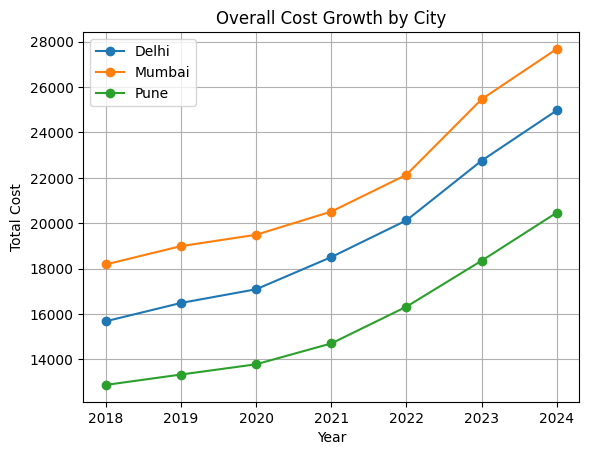

In [7]:
import matplotlib.pyplot as plt

for city, group in df.groupby("City"):
    plt.plot(group["Year"], group["Total_Cost"], marker='o', label=city)

plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.title("Overall Cost Growth by City")
plt.legend()
plt.grid(True)
plt.show()

In [9]:


# sort data
df = df.sort_values(["City", "Year"])

categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

result = []

for city, group in df.groupby("City"):
    city_result = {"City": city}
    
    for col in categories:
        first = group.iloc[0][col]
        last = group.iloc[-1][col]
        
        growth = ((last - first) / first) * 100
        city_result[col] = round(growth, 2)
    
    result.append(city_result)

growth_df = pd.DataFrame(result)

print(growth_df)

     City   Food   Fuel  Rent  Transport  Utilities  Entertainment
0   Delhi  63.16  51.28  60.0      61.11      47.83          71.43
1  Mumbai  65.00  50.00  50.0      60.00      44.00          73.33
2    Pune  61.11  57.33  62.5      53.33      40.00          75.00


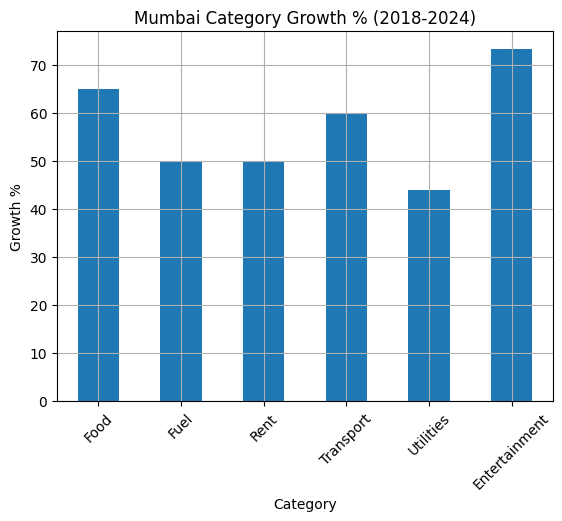

In [10]:
import matplotlib.pyplot as plt

city_name = "Mumbai"

city_data = growth_df[growth_df["City"] == city_name].drop("City", axis=1)

city_data.T.plot(kind='bar', legend=False)

plt.title(f"{city_name} Category Growth % (2018-2024)")
plt.ylabel("Growth %")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

     City   Food   Fuel  Rent  Transport  Utilities  Entertainment
0   Delhi  63.16  51.28  60.0      61.11      47.83          71.43
1  Mumbai  65.00  50.00  50.0      60.00      44.00          73.33
2    Pune  61.11  57.33  62.5      53.33      40.00          75.00


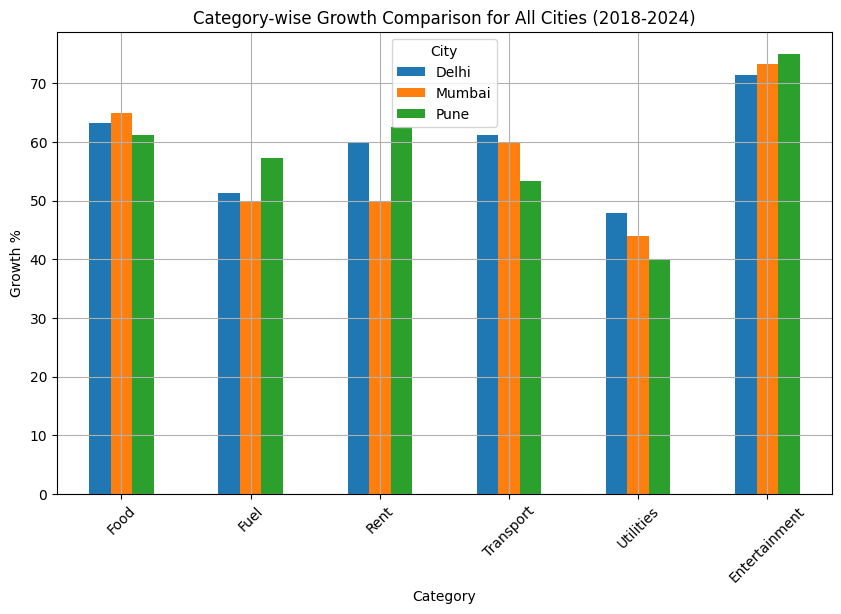

In [12]:

import pandas as pd
import matplotlib.pyplot as plt


# sort values
df = df.sort_values(["City", "Year"])

categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

result = []

# calculate growth % for each category in each city
for city, group in df.groupby("City"):
    city_result = {"City": city}
    
    for col in categories:
        first = group.iloc[0][col]
        last = group.iloc[-1][col]
        growth = ((last - first) / first) * 100
        city_result[col] = round(growth, 2)
    
    result.append(city_result)

growth_df = pd.DataFrame(result)

print(growth_df)

# set city as index for plotting
growth_df = growth_df.set_index("City")

# plot for all three cities
growth_df.T.plot(kind="bar", figsize=(10,6))

plt.title("Category-wise Growth Comparison for All Cities (2018-2024)")
plt.xlabel("Category")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="City")
plt.show()

In [14]:
import pandas as pd


categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

df["Total_Cost"] = df[categories].sum(axis=1)

df = df.sort_values(["City", "Year"])

In [15]:
df["Yearly_Growth_%"] = df.groupby("City")["Total_Cost"].pct_change() * 100
print(df[["City", "Year", "Total_Cost", "Yearly_Growth_%"]])

      City  Year  Total_Cost  Yearly_Growth_%
14   Delhi  2018       15673              NaN
15   Delhi  2019       16480         5.148982
16   Delhi  2020       17084         3.665049
17   Delhi  2021       18503         8.306017
18   Delhi  2022       20123         8.755337
19   Delhi  2023       22755        13.079561
20   Delhi  2024       24973         9.747308
0   Mumbai  2018       18180              NaN
1   Mumbai  2019       18987         4.438944
2   Mumbai  2020       19488         2.638647
3   Mumbai  2021       20510         5.244253
4   Mumbai  2022       22135         7.922964
5   Mumbai  2023       25465        15.044048
6   Mumbai  2024       27685         8.717848
7     Pune  2018       12865              NaN
8     Pune  2019       13323         3.560047
9     Pune  2020       13776         3.400135
10    Pune  2021       14695         6.671022
11    Pune  2022       16315        11.024158
12    Pune  2023       18342        12.424150
13    Pune  2024       20463      

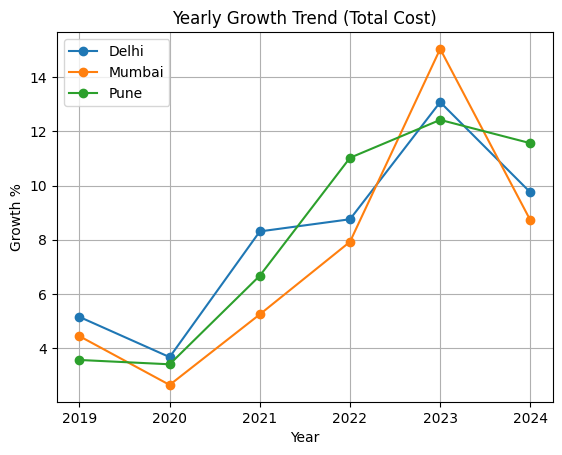

In [16]:
import matplotlib.pyplot as plt

for city, group in df.groupby("City"):
    plt.plot(group["Year"], group["Yearly_Growth_%"], marker='o', label=city)

plt.title("Yearly Growth Trend (Total Cost)")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
import pandas as pd



# category columns
categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# create total cost column
df["Total_Cost"] = df[categories].sum(axis=1)

# sort by city and year
df = df.sort_values(["City", "Year"])

leaderboard = []

# calculate overall growth city-wise
for city, group in df.groupby("City"):
    start_year = group.iloc[0]["Year"]
    end_year = group.iloc[-1]["Year"]
    
    start_total = group.iloc[0]["Total_Cost"]
    end_total = group.iloc[-1]["Total_Cost"]
    
    growth_percent = ((end_total - start_total) / start_total) * 100
    
    leaderboard.append({
        "City": city,
        "Start_Year": start_year,
        "End_Year": end_year,
        "Start_Total": start_total,
        "End_Total": end_total,
        "Overall_Growth_%": round(growth_percent, 2)
    })

# make dataframe
leaderboard_df = pd.DataFrame(leaderboard)

# rank cities by growth
leaderboard_df = leaderboard_df.sort_values("Overall_Growth_%", ascending=False).reset_index(drop=True)

# add rank column
leaderboard_df.index = leaderboard_df.index + 1
leaderboard_df["Rank"] = leaderboard_df.index

# rearrange columns
leaderboard_df = leaderboard_df[["Rank", "City", "Start_Year", "End_Year", "Start_Total", "End_Total", "Overall_Growth_%"]]

print(leaderboard_df)

   Rank    City  Start_Year  End_Year  Start_Total  End_Total  \
1     1   Delhi        2018      2024        15673      24973   
2     2    Pune        2018      2024        12865      20463   
3     3  Mumbai        2018      2024        18180      27685   

   Overall_Growth_%  
1             59.34  
2             59.06  
3             52.28  


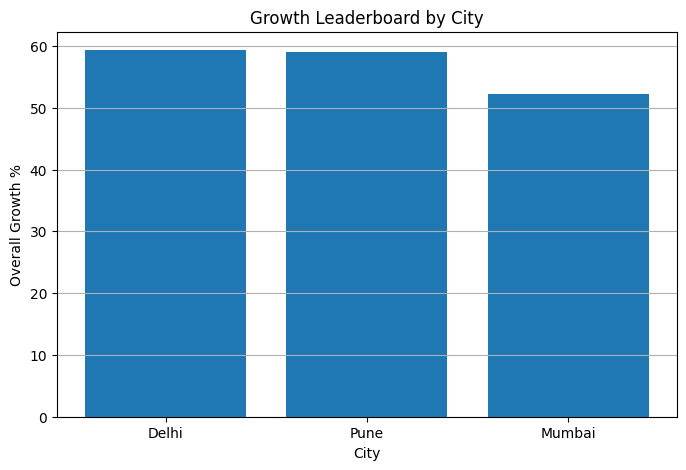

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(leaderboard_df["City"], leaderboard_df["Overall_Growth_%"])

plt.title("Growth Leaderboard by City")
plt.xlabel("City")
plt.ylabel("Overall Growth %")
plt.grid(axis='y')

plt.show()

In [20]:
top_city = leaderboard_df.iloc[0]["City"]
top_growth = leaderboard_df.iloc[0]["Overall_Growth_%"]

print(f"Highest inflation growth city: {top_city} ({top_growth}%)")

Highest inflation growth city: Delhi (59.34%)


In [ ]:
# ═══════════════════════════════════════════════════
# Export data to JSON for the Frontend Dashboard
# ═══════════════════════════════════════════════════
import json, os

OUT_DIR = "modern-dashboard/public"
os.makedirs(OUT_DIR, exist_ok=True)

# 1) Category-wise growth %
growth_df.to_json(os.path.join(OUT_DIR, "growth_data.json"), orient="records", indent=2)

# 2) Overall growth summary
overall_growth_df.to_json(os.path.join(OUT_DIR, "overall_growth.json"), orient="records", indent=2)

# 3) Full history (for trend & YoY charts)
cols = ["Year","City","Food","Fuel","Rent","Transport","Utilities","Entertainment","Total_Cost","Yearly_Growth_%"]
history = df[cols].copy()
history.to_json(os.path.join(OUT_DIR, "inflation_history.json"), orient="records", indent=2)

print("✅ growth.ipynb → exported growth_data.json, overall_growth.json, inflation_history.json")
